<a href="https://colab.research.google.com/github/2405301105-tech/Gen-ai-and-Agentic-ai/blob/main/ai_news_aggergator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain
!pip install langchain_groq
!pip install langchain-google-genai
!pip install langchain_tavily
!pip install langchain_community
!pip install ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [2]:
from dotenv import load_dotenv
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

True

In [4]:
from langchain_core.messages import SystemMessage
from langchain_groq import ChatGroq
llm = ChatGroq(model_name="llama-3.1-8b-instant")

Tavily **tool**

In [5]:
from langchain_tavily import TavilySearch
from langchain_core.tools import tool


In [6]:

_tavily_instance = TavilySearch(max_results=2)

@tool
def tavily_search(query: str) -> dict:
    "you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries."
    return _tavily_instance.invoke({"query": query})

In [7]:
search_query = "you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries"
response = tavily_search.invoke({"query": search_query})
print(response)

{'query': 'you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.facebook.com/AllSidesNow/posts/just-because-news-is-aggregated-from-different-sources-it-doesnt-mean-youre-gett/1541316154666463', 'title': 'including-google-apple-bing-allsides-updated- analysis ...', 'content': '... Bias Chart, the most balanced news sources are Associated Press and Reuters. The Associated Press earned a reliability score of 51.98 and a bias ...Read more', 'score': 0.44116792, 'raw_content': None}, {'url': 'https://www.readless.app/blog/best-unbiased-news-apps-2026', 'title': 'Best Unbiased News Apps: 8 Sources Tested (2026) | Blog | Readless', 'content': '## What are the best unbiased news apps in 2026? **Ground News and AllSides are the best apps for reading across the political spectrum in 2026, while Reuters and AP are the 

In [8]:
print(response["results"][0]["content"])

... Bias Chart, the most balanced news sources are Associated Press and Reuters. The Associated Press earned a reliability score of 51.98 and a bias ...Read more


In [9]:
response = tavily_search.invoke({"query": "you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries"})

In [10]:
print(response["results"][0]["content"])

... Bias Chart, the most balanced news sources are Associated Press and Reuters. The Associated Press earned a reliability score of 51.98 and a bias ...Read more


In [11]:
response

{'query': 'you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/AllSidesNow/posts/just-because-news-is-aggregated-from-different-sources-it-doesnt-mean-youre-gett/1541316154666463',
   'title': 'including-google-apple-bing-allsides-updated- analysis ...',
   'content': '... Bias Chart, the most balanced news sources are Associated Press and Reuters. The Associated Press earned a reliability score of 51.98 and a bias ...Read more',
   'score': 0.44116792,
   'raw_content': None},
  {'url': 'https://www.readless.app/blog/best-unbiased-news-apps-2026',
   'title': 'Best Unbiased News Apps: 8 Sources Tested (2026) | Blog | Readless',
   'content': '## What are the best unbiased news apps in 2026? **Ground News and AllSides are the best apps for reading across the political spectrum in 2026, while

**Summarize** article

In [12]:
@tool
def summarize_article(article_text: str) -> str:
    "."
    llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.3)
    prompt = f"Concisely summarize the following article text into exactly 3 bullet points:\n\n{article_text}"
    return llm.invoke(prompt).content

In [13]:
response

{'query': 'you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/AllSidesNow/posts/just-because-news-is-aggregated-from-different-sources-it-doesnt-mean-youre-gett/1541316154666463',
   'title': 'including-google-apple-bing-allsides-updated- analysis ...',
   'content': '... Bias Chart, the most balanced news sources are Associated Press and Reuters. The Associated Press earned a reliability score of 51.98 and a bias ...Read more',
   'score': 0.44116792,
   'raw_content': None},
  {'url': 'https://www.readless.app/blog/best-unbiased-news-apps-2026',
   'title': 'Best Unbiased News Apps: 8 Sources Tested (2026) | Blog | Readless',
   'content': '## What are the best unbiased news apps in 2026? **Ground News and AllSides are the best apps for reading across the political spectrum in 2026, while

DETECT **BIAS**

In [14]:
@tool
def detect_bias(summaries: str) -> str:
    "."
    llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.1)
    prompt = f"Compare coverage across these source summaries. Identify if any source has a bias (positive/negative/neutral):\n\n{summaries}"
    return llm.invoke(prompt).content

In [15]:
response

{'query': 'you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/AllSidesNow/posts/just-because-news-is-aggregated-from-different-sources-it-doesnt-mean-youre-gett/1541316154666463',
   'title': 'including-google-apple-bing-allsides-updated- analysis ...',
   'content': '... Bias Chart, the most balanced news sources are Associated Press and Reuters. The Associated Press earned a reliability score of 51.98 and a bias ...Read more',
   'score': 0.44116792,
   'raw_content': None},
  {'url': 'https://www.readless.app/blog/best-unbiased-news-apps-2026',
   'title': 'Best Unbiased News Apps: 8 Sources Tested (2026) | Blog | Readless',
   'content': '## What are the best unbiased news apps in 2026? **Ground News and AllSides are the best apps for reading across the political spectrum in 2026, while

TOOLS **USED**\bind the tools

In [16]:
from langchain_core.tools import tool

tools = [
    tavily_search,
    summarize_article,
    detect_bias
]

llm_tools = llm.bind_tools(tools)

**Guardials**

In [17]:
def deterministic_m(text: str) -> str:
  """this function returns if ban keyword is found return True
  else return false"""
  ban_keys = ["exploit", "vulnerability", "bypass", "backdoor", "playload"]
  text = text.lower()
  for i in ban_keys:
    if i in text:
      return True
  return False
  inp=["Summarize the new government cybersecurity policy to prevent a future cyber attack. (Legitimate news, but contains \"attack\")",
"What are the latest diplomatic talks to destroy economic inflation? (Metaphorical use, but contains \"destroy\")",
"Read the headline analysis on how tech companies are trying to hack-proof their new AI models."]

**GRAPH**

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


In [19]:
from typing import TypedDict, List
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
import json

class State(TypedDict):
    messages: List[BaseMessage]

# Define a maximum length for combined article content to prevent token limit errors
MAX_ARTICLE_CONTENT_LENGTH = 10000 # Approximately 2500 tokens for safety

SYSTEM_MESSAGE_CONTENT = (
    "You are a news analyst. You have just received *combined article content* from a `tavily_search` tool call. "
    "This content is directly available in the ToolMessage. "
    "Your task is now to analyze this combined content, which has been pre-processed to manage its length. "
    "You should call the `summarize_article` tool and pass the *relevant portions of the combined article content* as the `article_text` argument. "
    "Be mindful of the `summarize_article` tool's input limits, although the content has already been pre-truncated. "
    "After summarizing, if further analysis is needed (e.g., bias detection), you may use `detect_bias`. "
    "Always perform one tool call at a time. "
    "If no further tool use is necessary after reviewing the content, provide a direct, concise answer based on the information provided."
)
SYSTEM_MESSAGE = SystemMessage(content=SYSTEM_MESSAGE_CONTENT)

def tool_calling_llm(state:State):
    # Prepend the system message to the messages list
    messages_with_system_prompt = [SYSTEM_MESSAGE] + state["messages"]
    return {"messages":[llm_tools.invoke(messages_with_system_prompt)]}

def initial_tavily_search_node(state: State):
    # Extract the user's query from the latest HumanMessage
    user_query = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            user_query = msg.content
            break
    if not user_query:
        raise ValueError("No user query found to perform initial Tavily search.")

    print(f"DEBUG: Performing initial Tavily search for: {user_query}")
    search_results_dict = tavily_search.invoke({"query": user_query}) # Directly invoke the tool function

    # Extract content from each result and concatenate
    combined_article_content = ""
    if "results" in search_results_dict and search_results_dict["results"]:
        for result in search_results_dict["results"]:
            if "content" in result:
                combined_article_content += result["content"] + "\n\n"

    if not combined_article_content:
        # If no content is found, send a message indicating that.
        tool_message_content = "No relevant article content found in search results."
    else:
        # Truncate combined_article_content if it's too long
        if len(combined_article_content) > MAX_ARTICLE_CONTENT_LENGTH:
            combined_article_content = combined_article_content[:MAX_ARTICLE_CONTENT_LENGTH] + "\n\n... (content truncated)"
        tool_message_content = combined_article_content

    # Add processed search results as a ToolMessage to the messages list for the next step
    return {
        "messages": state["messages"] +
        [ToolMessage(content=tool_message_content, tool_call_id="tavily_search_initial_call")]
    }

In [20]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

workflow = StateGraph(State)
workflow.add_node("initial_search", initial_tavily_search_node)
workflow.add_node("tool_calling_llm", tool_calling_llm)
workflow.add_node("tools", ToolNode(tools))


workflow.add_edge(START, "initial_search")
workflow.add_edge("initial_search", "tool_calling_llm")
workflow.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END,
    },
)
# If a tool (summarize/detect_bias) is called, execute it, then end for now.
# Further steps could loop back to LLM for more analysis if needed.
workflow.add_edge("tools", END)

compiled_workflow = workflow.compile(checkpointer=memory)

In [21]:
built_graph = workflow.compile(checkpointer=memory)

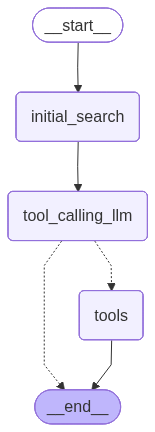

In [22]:
compiled_workflow

In [23]:
from langchain_core.messages import HumanMessage

query = {"messages": [HumanMessage(content="What is the latest breaking news about the global economy today?")]}

In [24]:
response

{'query': 'you are news analyst. search multiple sources for every query. always compare and look for bias. present blanced,balaced,factual summaries',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/AllSidesNow/posts/just-because-news-is-aggregated-from-different-sources-it-doesnt-mean-youre-gett/1541316154666463',
   'title': 'including-google-apple-bing-allsides-updated- analysis ...',
   'content': '... Bias Chart, the most balanced news sources are Associated Press and Reuters. The Associated Press earned a reliability score of 51.98 and a bias ...Read more',
   'score': 0.44116792,
   'raw_content': None},
  {'url': 'https://www.readless.app/blog/best-unbiased-news-apps-2026',
   'title': 'Best Unbiased News Apps: 8 Sources Tested (2026) | Blog | Readless',
   'content': '## What are the best unbiased news apps in 2026? **Ground News and AllSides are the best apps for reading across the political spectrum in 2026, while

In [25]:
config = {"recursion_limit": 50, "configurable": {"thread_id": "1"}}
response = compiled_workflow.invoke(query, config)

DEBUG: Performing initial Tavily search for: What is the latest breaking news about the global economy today?


In [26]:
response

{'messages': [ToolMessage(content='There is no article text provided to summarize. The given text appears to be a list of images and topics mentioned in a newsletter, but it does not contain any actual article content.', name='summarize_article', tool_call_id='qq9ke35jy')]}

In [27]:
from langchain_core.messages import HumanMessage
query = {"messages": [HumanMessage(content="current affair of india?")]}

In [28]:
response['messages'][-1].content

'There is no article text provided to summarize. The given text appears to be a list of images and topics mentioned in a newsletter, but it does not contain any actual article content.'

In [29]:
config = {"recursion_limit": 50, "configurable": {"thread_id": "2"}}
response = compiled_workflow.invoke(query, config)

DEBUG: Performing initial Tavily search for: current affair of india?


In [30]:
response = compiled_workflow.invoke(query, config)


DEBUG: Performing initial Tavily search for: current affair of india?


In [31]:
response

{'messages': [ToolMessage(content='{"query": "current affairs of India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://timesofindia.indiatimes.com/news", "title": "Latest News, Breaking News, Top News Headlines and Current Affairs | The Times of India", "content": "[Sophie Cunningham](https://timesofindia.indiatimes.com/sports/nba/top-stories/sophie-cunningham-shares-eye-catching-beach-moments-with-6-foot-2-fever-teammate/articleshow/132252791.cms \\"Sophie Cunningham\\")[Stephen A Smith Controversy](https://timesofindia.indiatimes.com/sports/nba/top-stories/stephen-a-smith-and-draymond-greens-feud-explained-what-sparked-the-latest-beef/articleshow/132276291.cms \\"Stephen A Smith Controversy\\")[India Vs Sri Lanka U19](https://timesofindia.indiatimes.com/sports/cricket/india-u19-vs-sri-lanka-u19-3rd-unofficial-odi-live-score-ind-vs-sl-cricket-match-today-scorecard-live-streaming-weather-report-commentary-highlights-latest-news/liveblog/1322762